# Step1 : Identifing The Business Problem :
## Building a machine learning model that predicts the Risk Category of EV users based on their charging habits, energy usage patterns, and financial indicators. 

# Import Libraries

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2 : Load the Dataset and Identify Basic Checks

In [77]:
df = pd.read_csv("EV Charging Behavior Dataset.csv")

In [78]:
df.head()

,User_ID,Age,City_Tier,EV_Type,Battery_Capacity_kWh,Charging_Sessions_Per_Month,Avg_Charge_Cost,Distance_Travelled_Per_Month,Income_Level,Loan_Taken,Missed_Payments_Last_6M,Tenure_Months,Charging_Location_Type,App_Usage_Score,Charger_Working_Status,Charging_Time_Minutes,High_Default_Risk,Charging_Efficiency_Index
0,1,59,Tier3,5KW,40.7,19,325.10,1702,Low,0,2,1,Public,1,Working,58.5,0,100.00
1,2,49,Tier5,5KW,31.7,9,439.97,2377,High,0,0,1,Highway,7,Working,47.0,0,96.36
2,3,35,Tier5,5KW,36.8,24,309.80,1905,Low,0,5,6,Highway,4,Working,53.5,1,100.00
3,4,63,Tier5,2KW,38.5,32,353.90,2074,Medium,0,1,31,Highway,1,Not Working,112.0,1,57.96
4,5,28,Tier1,5KW,33.2,8,597.43,1212,Medium,0,2,24,Private,6,Working,58.0,0,84.56


In [79]:
df.shape

(18946, 18)

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18946 entries, 0 to 18945
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   User_ID                       18946 non-null  int64  
 1   Age                           18946 non-null  int64  
 2   City_Tier                     18946 non-null  object 
 3   EV_Type                       18946 non-null  object 
 4   Battery_Capacity_kWh          18946 non-null  float64
 5   Charging_Sessions_Per_Month   18946 non-null  int64  
 6   Avg_Charge_Cost               18946 non-null  float64
 7   Distance_Travelled_Per_Month  18946 non-null  int64  
 8   Income_Level                  18946 non-null  object 
 9   Loan_Taken                    18946 non-null  int64  
 10  Missed_Payments_Last_6M       18946 non-null  int64  
 11  Tenure_Months                 18946 non-null  int64  
 12  Charging_Location_Type        18946 non-null  object 
 13  A

In [81]:
df.describe()

,User_ID,Age,Battery_Capacity_kWh,Charging_Sessions_Per_Month,Avg_Charge_Cost,Distance_Travelled_Per_Month,Loan_Taken,Missed_Payments_Last_6M,Tenure_Months,App_Usage_Score,Charging_Time_Minutes,High_Default_Risk,Charging_Efficiency_Index
count,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000,18946.000000
mean,9473.500000,42.919930,35.027890,19.496358,450.124728,1399.960044,0.408266,2.489866,24.096749,5.510767,62.940257,0.443999,87.653957
std,5469.383436,12.915867,10.047099,8.656905,120.149182,635.388130,0.491526,1.701978,13.583756,2.870352,32.274571,0.496867,25.041681
min,1.000000,21.000000,-8.000000,5.000000,-85.560000,300.000000,0.000000,0.000000,1.000000,1.000000,-14.100000,0.000000,0.000000
25%,4737.250000,32.000000,28.300000,12.000000,370.190000,848.250000,0.000000,1.000000,12.000000,3.000000,43.100000,0.000000,90.360000
50%,9473.500000,43.000000,35.100000,19.000000,449.640000,1399.500000,0.000000,2.000000,24.000000,6.000000,55.600000,0.000000,100.000000
75%,14209.750000,54.000000,41.900000,27.000000,530.467500,1951.000000,1.000000,4.000000,36.000000,8.000000,71.000000,1.000000,100.000000
max,18946.000000,65.000000,72.500000,34.000000,901.220000,2499.000000,1.000000,5.000000,47.000000,10.000000,278.200000,1.000000,100.000000


In [82]:
df.isnull().sum()

User_ID                         0
Age                             0
City_Tier                       0
EV_Type                         0
Battery_Capacity_kWh            0
Charging_Sessions_Per_Month     0
Avg_Charge_Cost                 0
Distance_Travelled_Per_Month    0
Income_Level                    0
Loan_Taken                      0
Missed_Payments_Last_6M         0
Tenure_Months                   0
Charging_Location_Type          0
App_Usage_Score                 0
Charger_Working_Status          0
Charging_Time_Minutes           0
High_Default_Risk               0
Charging_Efficiency_Index       0
dtype: int64

In [83]:
df.isnull().sum()/len(df)*100

User_ID                         0.0
Age                             0.0
City_Tier                       0.0
EV_Type                         0.0
Battery_Capacity_kWh            0.0
Charging_Sessions_Per_Month     0.0
Avg_Charge_Cost                 0.0
Distance_Travelled_Per_Month    0.0
Income_Level                    0.0
Loan_Taken                      0.0
Missed_Payments_Last_6M         0.0
Tenure_Months                   0.0
Charging_Location_Type          0.0
App_Usage_Score                 0.0
Charger_Working_Status          0.0
Charging_Time_Minutes           0.0
High_Default_Risk               0.0
Charging_Efficiency_Index       0.0
dtype: float64

# Step 3 : Exploratory Data Analysis

# **1. UNIVARIATE ANALYSIS (Single Variable)**

## **A) Numerical Columns**

### **Histogram**

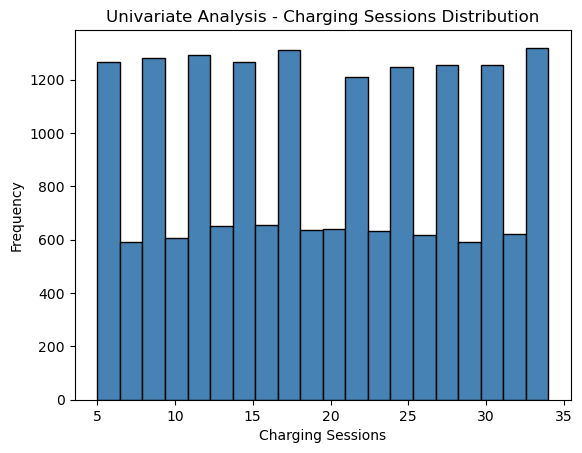

In [84]:
# Numerical Univariate - Temperature
plt.figure()
plt.hist(df['Charging_Sessions_Per_Month'], bins=20, color='steelblue', edgecolor='black')
plt.title('Univariate Analysis - Charging Sessions Distribution')
plt.xlabel('Charging Sessions')
plt.ylabel('Frequency')
plt.show()

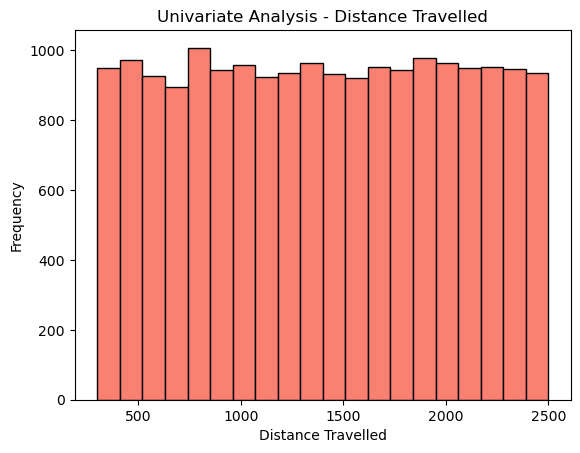

In [85]:
# Numerical Univariate - High Default Risk   (Target Variable)
plt.figure()
plt.hist(df['Distance_Travelled_Per_Month'], bins=20, color='salmon', edgecolor='black')
plt.title('Univariate Analysis - Distance Travelled')
plt.xlabel('Distance Travelled')
plt.ylabel('Frequency')
plt.show()

## **B) Categorical Columns**

### **Countplot (Bar Chart)**

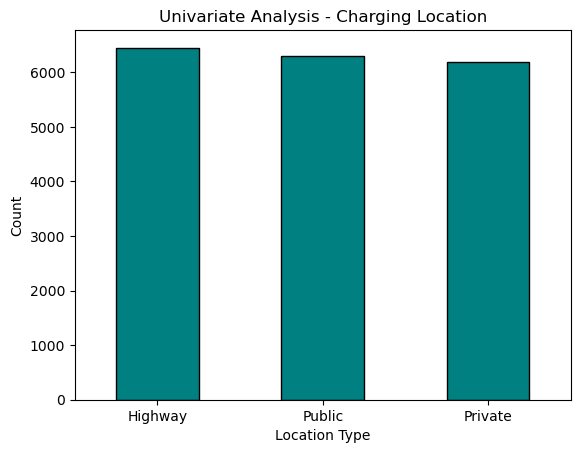

In [86]:
# Categorical Univariate
plt.figure()
df['Charging_Location_Type'].value_counts().plot(kind='bar', color='teal', edgecolor='black')
plt.title('Univariate Analysis - Charging Location')
plt.xlabel("Location Type")
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

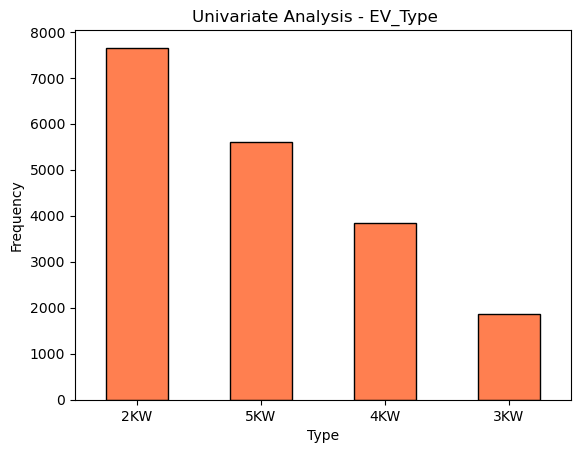

In [87]:
# Categorical Univariate - EV Type
plt.figure()
df['EV_Type'].value_counts().plot(kind='bar', color='coral', edgecolor='black')
plt.title('Univariate Analysis - EV_Type   ')
plt.xlabel('Type')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.show()

# **2. BIVARIATE ANALYSIS (Two Variables)**

## **A) Numerical vs Numerical**

### **Scatter Plot**

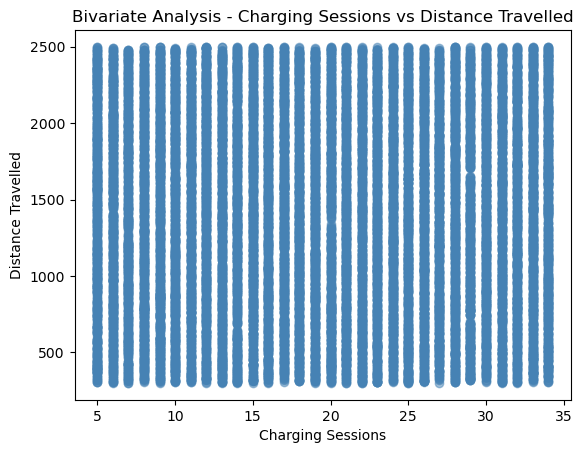

In [88]:
plt.figure()
plt.scatter(df['Charging_Sessions_Per_Month'], df['Distance_Travelled_Per_Month'], alpha=0.5, color='steelblue')
plt.title('Bivariate Analysis - Charging Sessions vs Distance Travelled')
plt.xlabel('Charging Sessions')
plt.ylabel('Distance Travelled')
plt.show()

## **B) Numerical vs Categorical**

### **Boxplot**

<Figure size 640x480 with 0 Axes>

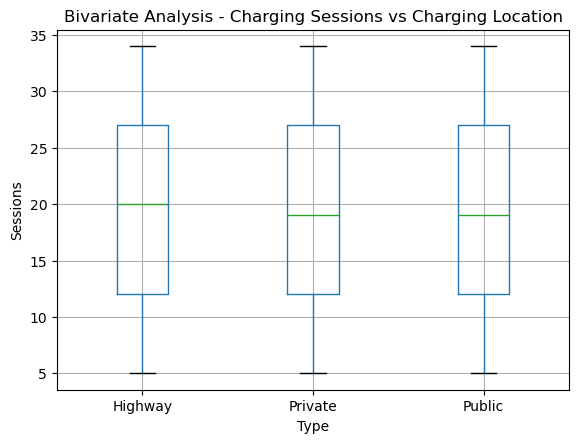

In [89]:
plt.figure()
df.boxplot(column='Charging_Sessions_Per_Month', by='Charging_Location_Type')
plt.title('Bivariate Analysis - Charging Sessions vs Charging Location')
plt.suptitle('')
plt.xlabel('Type')
plt.ylabel('Sessions')
plt.show()

## **C) Categorical vs Categorical**

### **Count Plot**

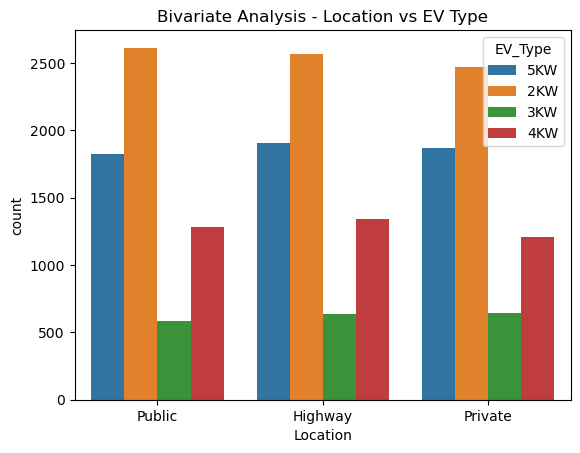

In [90]:
plt.figure()
sns.countplot(x='Charging_Location_Type', hue='EV_Type', data=df)
plt.title('Bivariate Analysis - Location vs EV Type')
plt.xlabel('Location')
plt.show()

# **Step 4 : Preprocessing**

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18946 entries, 0 to 18945
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   User_ID                       18946 non-null  int64  
 1   Age                           18946 non-null  int64  
 2   City_Tier                     18946 non-null  object 
 3   EV_Type                       18946 non-null  object 
 4   Battery_Capacity_kWh          18946 non-null  float64
 5   Charging_Sessions_Per_Month   18946 non-null  int64  
 6   Avg_Charge_Cost               18946 non-null  float64
 7   Distance_Travelled_Per_Month  18946 non-null  int64  
 8   Income_Level                  18946 non-null  object 
 9   Loan_Taken                    18946 non-null  int64  
 10  Missed_Payments_Last_6M       18946 non-null  int64  
 11  Tenure_Months                 18946 non-null  int64  
 12  Charging_Location_Type        18946 non-null  object 
 13  A

In [92]:
df = df.drop(columns=['User_ID', 'App_Usage_Score'])
df.head()

,Age,City_Tier,EV_Type,Battery_Capacity_kWh,Charging_Sessions_Per_Month,Avg_Charge_Cost,Distance_Travelled_Per_Month,Income_Level,Loan_Taken,Missed_Payments_Last_6M,Tenure_Months,Charging_Location_Type,Charger_Working_Status,Charging_Time_Minutes,High_Default_Risk,Charging_Efficiency_Index
0,59,Tier3,5KW,40.7,19,325.10,1702,Low,0,2,1,Public,Working,58.5,0,100.00
1,49,Tier5,5KW,31.7,9,439.97,2377,High,0,0,1,Highway,Working,47.0,0,96.36
2,35,Tier5,5KW,36.8,24,309.80,1905,Low,0,5,6,Highway,Working,53.5,1,100.00
3,63,Tier5,2KW,38.5,32,353.90,2074,Medium,0,1,31,Highway,Not Working,112.0,1,57.96
4,28,Tier1,5KW,33.2,8,597.43,1212,Medium,0,2,24,Private,Working,58.0,0,84.56


In [93]:
# Check for duplicate rows
df.duplicated().sum()

0

<Axes: >

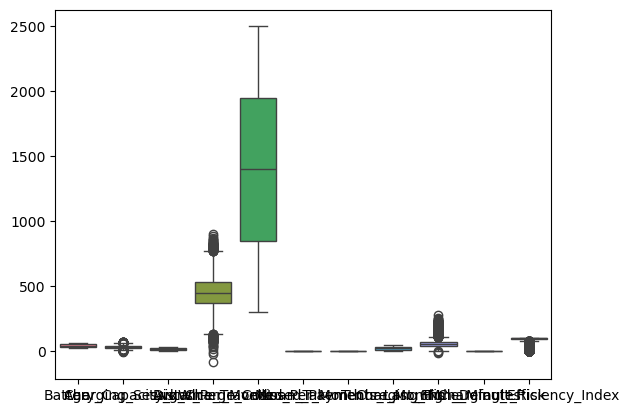

In [94]:
# Outlier Check
sns.boxplot(df)

In [97]:
df.shape

(18946, 16)

In [99]:
# Define Target variable
y = df['High_Default_Risk']
print(y.shape)

(18946,)


In [100]:
# Define Predictors (Input Variables)
X = df.drop(columns='High_Default_Risk')
X.shape

(18946, 15)

In [101]:
X.columns

Index(['Age', 'City_Tier', 'EV_Type', 'Battery_Capacity_kWh',
       'Charging_Sessions_Per_Month', 'Avg_Charge_Cost',
       'Distance_Travelled_Per_Month', 'Income_Level', 'Loan_Taken',
       'Missed_Payments_Last_6M', 'Tenure_Months', 'Charging_Location_Type',
       'Charger_Working_Status', 'Charging_Time_Minutes',
       'Charging_Efficiency_Index'],
      dtype='object')

In [102]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18946 entries, 0 to 18945
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age                           18946 non-null  int64  
 1   City_Tier                     18946 non-null  object 
 2   EV_Type                       18946 non-null  object 
 3   Battery_Capacity_kWh          18946 non-null  float64
 4   Charging_Sessions_Per_Month   18946 non-null  int64  
 5   Avg_Charge_Cost               18946 non-null  float64
 6   Distance_Travelled_Per_Month  18946 non-null  int64  
 7   Income_Level                  18946 non-null  object 
 8   Loan_Taken                    18946 non-null  int64  
 9   Missed_Payments_Last_6M       18946 non-null  int64  
 10  Tenure_Months                 18946 non-null  int64  
 11  Charging_Location_Type        18946 non-null  object 
 12  Charger_Working_Status        18946 non-null  object 
 13  C

# Encoding and Scaling

In [110]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder

In [111]:
ts = ColumnTransformer(transformers=[("t1",StandardScaler(),[0,3,4,5,6,8,9,10,13,14]),
                                    ("t2",OneHotEncoder(),[1,2,7,11,12])])

In [112]:
X_transform = ts.fit_transform(X)

In [117]:
X_transform = pd.DataFrame(
    X_transform,
    columns=ts.get_feature_names_out()
)

# **Step 5 : Feature Selection**

In [118]:
from sklearn.feature_selection import mutual_info_regression
mi = mutual_info_regression(X_transform, y)
mi = pd.Series(mi)
mi.index = X_transform.columns
mi.sort_values(ascending=False)

t1__Charging_Efficiency_Index             0.079954
t2__Charger_Working_Status_Not Working    0.078236
t1__Charging_Time_Minutes                 0.072094
t2__Charger_Working_Status_Working        0.068882
t1__Loan_Taken                            0.064040
t1__Missed_Payments_Last_6M               0.058395
t1__Charging_Sessions_Per_Month           0.047162
t2__Income_Level_Low                      0.045882
t2__Income_Level_Medium                   0.023362
t1__Battery_Capacity_kWh                  0.011716
t1__Tenure_Months                         0.005909
t2__City_Tier_Tier2                       0.003734
t2__EV_Type_2KW                           0.003546
t2__City_Tier_Tier1                       0.002105
t2__Charging_Location_Type_Public         0.000000
t2__Income_Level_High                     0.000000
t2__Charging_Location_Type_Private        0.000000
t2__Charging_Location_Type_Highway        0.000000
t1__Age                                   0.000000
t2__EV_Type_5KW                

# **Step 6 : Split the Data (Train Test Split)**

In [119]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('X_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)
print('X_test shape:', x_test.shape)
print('y_test shape:', y_test.shape)

X_train shape: (15156, 15)
y_train shape: (15156,)
X_test shape: (3790, 15)
y_test shape: (3790,)


In [121]:
X_train_trans = ts.fit_transform(x_train)
X_train_trans = pd.DataFrame(X_train_trans, columns=ts.get_feature_names_out())
X_train_trans.head()

,t1__Age,t1__Battery_Capacity_kWh,t1__Charging_Sessions_Per_Month,t1__Avg_Charge_Cost,t1__Distance_Travelled_Per_Month,t1__Loan_Taken,t1__Missed_Payments_Last_6M,t1__Tenure_Months,t1__Charging_Time_Minutes,t1__Charging_Efficiency_Index,...,t2__EV_Type_4KW,t2__EV_Type_5KW,t2__Income_Level_High,t2__Income_Level_Low,t2__Income_Level_Medium,t2__Charging_Location_Type_Highway,t2__Charging_Location_Type_Private,t2__Charging_Location_Type_Public,t2__Charger_Working_Status_Not Working,t2__Charger_Working_Status_Working
0,0.166057,-2.488655,0.518646,-1.687730,-1.192528,1.201061,-0.870143,-1.180412,-1.579345,0.491397,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
1,0.941898,-1.079863,0.980674,0.018297,0.891018,-0.832598,-0.284743,1.318812,-0.682755,0.491397,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
2,-0.299449,0.715852,-0.405410,0.220058,0.141949,-0.832598,0.300657,-0.665866,-0.248421,0.491397,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
3,-1.075290,-0.811994,1.096181,1.129107,0.752535,-0.832598,-0.870143,-0.445346,-0.493510,0.491397,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
4,-0.144280,-0.881441,-1.560480,0.620752,-0.921856,-0.832598,-1.455542,0.216213,-0.794441,0.317826,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0


In [123]:
X_test_trans = ts.transform(x_test)
X_test_trans = pd.DataFrame(X_test_trans, columns=ts.get_feature_names_out())
X_test_trans.head()

,t1__Age,t1__Battery_Capacity_kWh,t1__Charging_Sessions_Per_Month,t1__Avg_Charge_Cost,t1__Distance_Travelled_Per_Month,t1__Loan_Taken,t1__Missed_Payments_Last_6M,t1__Tenure_Months,t1__Charging_Time_Minutes,t1__Charging_Efficiency_Index,...,t2__EV_Type_4KW,t2__EV_Type_5KW,t2__Income_Level_High,t2__Income_Level_Low,t2__Income_Level_Medium,t2__Charging_Location_Type_Highway,t2__Charging_Location_Type_Private,t2__Charging_Location_Type_Public,t2__Charger_Working_Status_Not Working,t2__Charger_Working_Status_Working
0,0.321225,0.874589,-1.560480,-1.839820,0.009760,1.201061,-1.455542,-0.812879,0.310008,-0.543599,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
1,1.484988,0.596799,0.172125,-1.163982,1.649530,-0.832598,0.300657,-0.518853,-0.220500,0.491397,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
2,-1.695964,-0.097676,-0.751931,0.970610,-0.301828,-0.832598,-1.455542,-0.518853,-0.208090,0.374879,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,-0.687369,0.100745,0.056618,-0.343625,0.585725,1.201061,0.886056,-0.298333,-0.121224,0.491397,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
4,-0.066696,-0.028229,1.442702,0.126374,-0.898251,1.201061,0.300657,0.951279,-0.440769,0.491397,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0


# Knn Classification

In [128]:
#KNN Classification
from sklearn.neighbors import KNeighborsClassifier
knr = KNeighborsClassifier(n_neighbors=3)

In [129]:
knr.fit(X_train_trans,y_train)

KNeighborsClassifier(n_neighbors=3)

## Test

In [130]:
#prediction
y_pred = knr.predict(X_test_trans)
print(y_pred.shape)
print(y_test.shape)

(3790,)
(3790,)


In [131]:
# Let us use accuracy score to validate this model
from sklearn.metrics import accuracy_score
score=accuracy_score(y_pred,y_test)
print("Accuracy Score of KNN Classifier is ",score)

Accuracy Score of KNN Classifier is  0.8


## train

In [134]:
#prediction
y_pred = knr.predict(X_train_trans)
print(y_pred.shape)
print(y_train.shape)

(15156,)
(15156,)


In [136]:
# Let us use accuracy score to validate this model
from sklearn.metrics import accuracy_score
score=accuracy_score(y_pred,y_train)
print("Accuracy Score of KNN Classifier is ",score)

Accuracy Score of KNN Classifier is  0.9053180258643442


# RandomForest Classifier

In [140]:
from sklearn. ensemble import RandomForestClassifier    # importing randomforest

rf_clf = RandomForestClassifier() # Assigning RandomForest CLassifier into variable

rf_clf.fit(X_train_trans,y_train)  # training the data

RandomForestClassifier()

In [141]:
# Validating the model
y_predict=rf_clf.predict(X_test_trans)

In [142]:
accuracy_score(y_test, y_predict) # Checking the accuracy

0.8588390501319261

# Decision Tree`

In [155]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()